# Principal Component Analysis — Fetal Health Classification

We run PCA on the 21 numerical CTG features from the fetal
health dataset (excluding the expert `fetal_health` label)
after standardization. The first two components give a
quick 2-D picture of how separable the three classes are in
linear subspace.

$$X_c = U S V^\top, \quad \text{components} = V^\top.$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.pre_processing import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.unsupervised_learning.decomposition import PCA
from rice_ml.processing.pre_processing import StandardScaler

df = pd.read_csv(find_data_file("fetal_health.csv"))
y = df["fetal_health"].to_numpy(dtype=int)
X = df.drop(columns=["fetal_health"]).to_numpy(dtype=float)
X_s = StandardScaler().fit_transform(X)

variance explained by 2 PCs = 45.6%


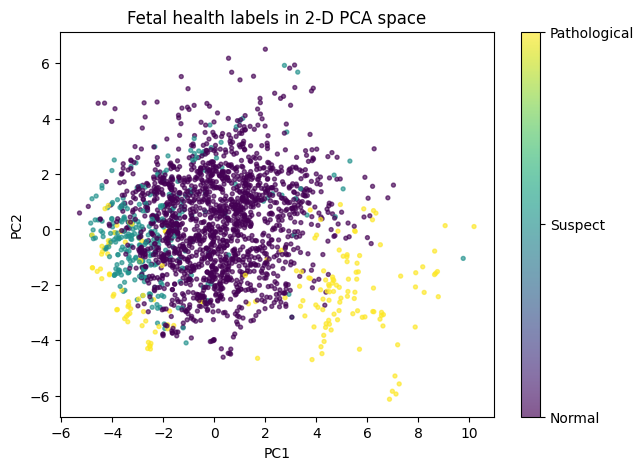

In [3]:
pca = PCA(n_components=2).fit(X_s)
Z = pca.transform(X_s)
print(
    "variance explained by 2 PCs = "
    f"{pca.explained_variance_ratio_.sum() * 100:.1f}%"
)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="viridis", s=8, alpha=0.65)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Fetal health labels in 2-D PCA space")
cbar = plt.colorbar(sc, ax=ax, ticks=[1, 2, 3])
cbar.ax.set_yticklabels(["Normal", "Suspect", "Pathological"])
plt.show()

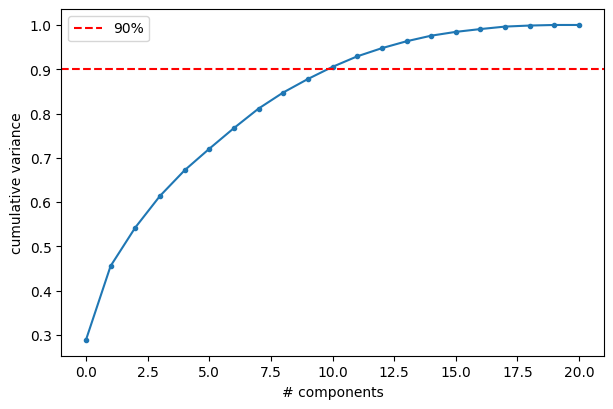

11 components -> 90% variance


In [4]:
pca_full = PCA().fit(X_s)
cum = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots()
ax.plot(cum, marker=".")
ax.axhline(0.9, color="red", linestyle="--", label="90%")
ax.set_xlabel("# components")
ax.set_ylabel("cumulative variance")
ax.legend()
plt.show()

print(f"{int(np.argmax(cum >= 0.9)) + 1} components -> 90% variance")

## Takeaways

- PCA is unsupervised: components maximize variance, not
  class separation (cf. LDA).
- If many components are needed for 90% variance, the
  feature space is inherently high-rank.
- 2-D PCA is a useful first visualization before harder
  classifiers.